In [43]:
from transformers import CLIPProcessor, CLIPModel
import torch
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
from notworLeUtils.notworle_utils.dataset import FolderImage
from notworLeUtils.notworle_utils.matplotlib import draw_plot
import pandas as pd
import torch.nn.functional as F

In [2]:
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

config.json: 0.00B [00:00, ?B/s]

C:\Users\Huy Le\AppData\Roaming\Python\Python312\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Huy Le\.cache\huggingface\hub\models--openai--clip-vit-base-patch32. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

torch.Size([1, 768])


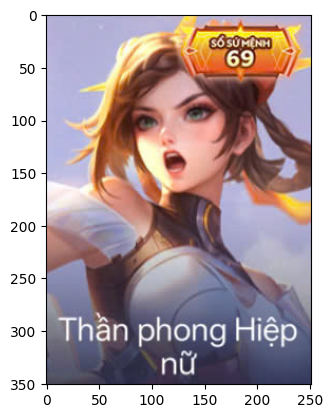

In [66]:
image_path = r"C:\Users\Huy Le\Downloads\z7698678683830_b861dd743993ee4ea96bc65e977399b3.jpg"
image_input = cv2.imread(image_path, cv2.IMREAD_COLOR_RGB)
# image_input = cv2.blur(image_input, (9, 9))
if image_input is None:
    raise ValueError("Ảnh fail")

pixel_values = processor(images=image_input, return_tensors="pt")["pixel_values"]
with torch.no_grad():
    output  = model.vision_model(pixel_values=pixel_values)

image_input_embedding = output.pooler_output  # [1, 768]
print(image_input_embedding.shape)
plt.imshow(image_input)
plt.show()

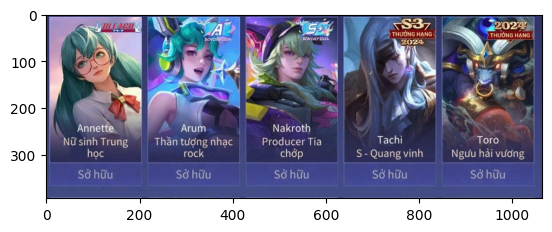

In [80]:
img5 = cv2.imread(r"D:\gitvanhub\Computer_vision_intergration\projects\dataset\input\img.png", cv2.IMREAD_COLOR_RGB)

plt.imshow(img5)
plt.show()

Số card: 5


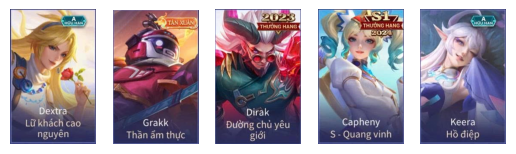

In [90]:
import cv2
import numpy as np

img = cv2.imread(r"D:\gitvanhub\Computer_vision_intergration\projects\dataset\input\img_1.png", cv2.IMREAD_COLOR_RGB)
orig = img.copy()

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 1. Blur + edge
blur = cv2.GaussianBlur(gray, (5,5), 0)
edges = cv2.Canny(blur, 50, 150)

# 2. Dilate để nối cạnh (rất quan trọng)
kernel = np.ones((3,3), np.uint8)
edges = cv2.dilate(edges, kernel, iterations=1)

# 3. Find contours
contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

rects = []

for cnt in contours:
    area = cv2.contourArea(cnt)
    if area < 2000:  # lọc nhiễu nhỏ
        continue

    # approx polygon
    approx = cv2.approxPolyDP(cnt, 0.02 * cv2.arcLength(cnt, True), True)

    if len(approx) == 4:
        x, y, w, h = cv2.boundingRect(approx)

        # lọc theo tỷ lệ (card thường cao hơn rộng)
        ratio = h / w
        if 1.2 < ratio < 2.5:
            rects.append((x, y, w, h))

# 4. sort theo hàng (trái -> phải, trên -> dưới)
rects = sorted(rects, key=lambda x: (x[1]//100, x[0]))

# 5. crop
crops = []
titles =[]
for i, (x, y, w, h) in enumerate(rects):
    crop = orig[y:y+h, x:x+w]
    crops.append(crop)
    titles.append(i)


print("Số card:", len(rects))
fig, axes = plt.subplots(1, 5 )
for ax, image in zip(axes, crops):
    ax.imshow(image)
    ax.axis('off')
plt.show()

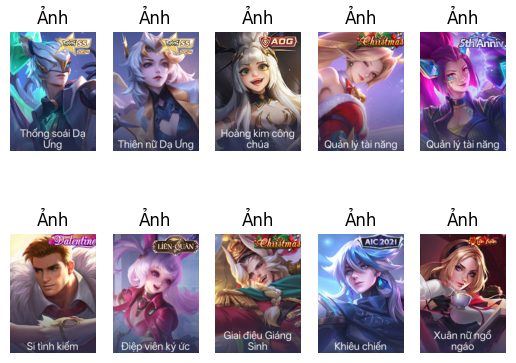

In [46]:
dataset_path = (Path.cwd() / ".." / "dataset" / "anhfull").resolve()
if not Path.exists(dataset_path):
    raise ValueError(f"Path: {dataset_path} k ton tai")

dataset = FolderImage(dataset_path)
n = 10

fig, axes = plt.subplots(n //5, 5)
titles = []
images = []
for i in range(n):
    image, name, path = dataset[i]
    titles.append('Ảnh')
    images.append(image)

draw_plot(axes, titles, images)
plt.show()

In [65]:
embedding_db = []
for i in range(len(dataset)):
    image, name, path = dataset[i]
    pixel_values = processor(images=image, return_tensors="pt")["pixel_values"]
    with torch.no_grad():
        output  = model.vision_model(pixel_values=pixel_values)

    features = output.pooler_output  # [1, 768]
    embedding_db.append(features)
print(len(embedding_db))

398


In [68]:
cos_sim = [F.cosine_similarity(image_input_embedding, embed) for embed in embedding_db]
pd.DataFrame(cos_sim)

,0
0,tensor(0.7011)
1,tensor(0.6798)
2,tensor(0.7210)
3,tensor(0.6790)
4,tensor(0.6218)
...,...
393,tensor(0.7223)
394,tensor(0.5889)
395,tensor(0.6488)
396,tensor(0.6187)


Ảnh 275
Con sim 0.8918532729148865


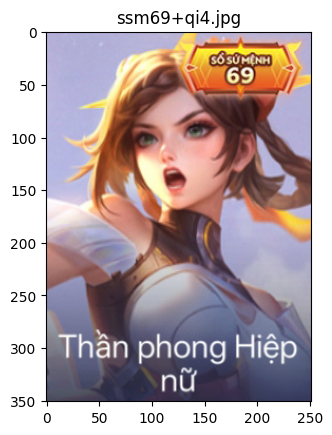

In [70]:
values = [v.item() for v in cos_sim]
max_val = max(values)
max_idx = values.index(max_val)

print(f"Ảnh {max_idx}")
print(f"Con sim {max_val}")

# lấy ảnh 2
image, name, path = dataset[max_idx]

image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.title(name)
plt.imshow(image)
plt.show()